# BERT

- Normal this word embedding word2vec is wont keep contextual meaning. BERT will keep contextual meaning and generates vector.
- Normally word2vec generates vector for individual word, but BERT will generate single vector for entire sentence 
- BERT used in NLP

- Here is the page that has list of all available bert models on tensorflow hub that one can download and make use of.

https://tfhub.dev/google/collections/bert/1

- Here is the information on basic uncased BERT model,

https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4

- It uses L=12 hidden layers (i.e., Transformer blocks), a hidden size of H=768, and A=12 attention heads. This model has been pre-trained for English on the Wikipedia and BooksCorpus.

In [6]:
import tensorflow_hub as hub
import tensorflow_text as text

In [9]:
preprocess_url = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
encoder_url = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"


In [10]:
#This is like function pointer, inside this poinetr we can pass any statement and it will do preprocessing
# This is preprocessing 1st layer
bert_preprocess_model = hub.KerasLayer(preprocess_url)

In [16]:
text_test = ['nice movie indeed','I love python programming nice']
text_preprocessed = bert_preprocess_model(text_test)

text_preprocessed.keys()

dict_keys(['input_mask', 'input_type_ids', 'input_word_ids'])

> # This produces dictionary of 3 keys and each with 2 lists
> 1st is input mask with 2 list. 1st line has 3 words, but it produced 5 values as 1. This means "cls ,nice, movie, indeed, Sep"

> For each line it adds cls at the starting and seperator sep as the end

In [17]:
text_preprocessed['input_mask']

<tf.Tensor: shape=(2, 128), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])>

In [18]:
text_preprocessed['input_type_ids']

<tf.Tensor: shape=(2, 128), dtype=int32, numpy=
array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])>

In [19]:
text_preprocessed['input_word_ids']

<tf.Tensor: shape=(2, 128), dtype=int32, numpy=
array([[  101,  3835,  3185,  5262,   102,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

> For each line it adds cls at the starting and seperator sep as the end.

> input_word_ids are for each of this word gives unique id, these are id from vocabulary

> For example 1st line has word "nice" as 1st place and 2nd line has word "nice" as last word. both having same value = 3835

#### 101 --> CLS token

#### 102 --> SEP token

BERT uses CLS as a special token at the begining of each setence whereas SEP as a special token to separate two sentences or end sinle sentece

In [21]:
# This is  2nd layer which will have encoder url, which will word endcoding
bert_model = hub.KerasLayer(encoder_url)

In [22]:
#Its like a funct pointer, it calls encoder_url 
bert_results = bert_model(text_preprocessed)

In [23]:
bert_results.keys()

dict_keys(['default', 'encoder_outputs', 'pooled_output', 'sequence_output'])

> Which has 4 keys, pooled output is embedding for the entire sentence

In [25]:
bert_results['sequence_output']

<tf.Tensor: shape=(2, 128, 768), dtype=float32, numpy=
array([[[ 0.07292049,  0.08567821,  0.14476839, ..., -0.09677093,
          0.08722146,  0.07711097],
        [ 0.17839389, -0.19006066,  0.5034941 , ..., -0.05869843,
          0.3271714 , -0.15578581],
        [ 0.18701449, -0.43388772, -0.48875144, ..., -0.1550277 ,
          0.00145138, -0.24470966],
        ...,
        [ 0.12083028,  0.12884237,  0.46453524, ...,  0.07375555,
          0.17441934,  0.16522118],
        [ 0.07967854, -0.01190679,  0.5022541 , ...,  0.1377775 ,
          0.21002212,  0.00624582],
        [-0.0721269 , -0.2830347 ,  0.59033364, ...,  0.47551933,
          0.1666847 , -0.08920315]],

       [[-0.05533914,  0.1887488 , -0.19368494, ..., -0.1453175 ,
          0.21719882,  0.6776633 ],
        [ 0.3302325 ,  0.14483654, -0.35440895, ...,  0.08010809,
          0.45744348,  0.437999  ],
        [ 0.8402248 ,  0.9561045 ,  0.39044964, ...,  0.30778673,
          0.40883586,  0.3707441 ],
        ...,

> This is individual words embedding vector  ,here shape=(2, 128, 768), means 2 line , 128 is like each line we will have padding and it becomes size of 128 words. and 768 values for each word. Ex : for word "nice" it will have 768 values.

> 128 Padding:  nice movie indeed 0 0 0 0 ... 0 ---> 128

In [24]:
bert_results['pooled_output']

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.7917741 , -0.2141193 ,  0.49769488, ...,  0.2446516 ,
        -0.47334483,  0.81758714],
       [-0.85537875, -0.39375362, -0.6487845 , ..., -0.5068655 ,
        -0.65967375,  0.8850023 ]], dtype=float32)>

> This is whole sentences  embedding vector, here shape=(2, 768), means 2 line and 768 values for each line

> pooled output is embedding for the entire sentence for each sentence it produces 2 list represent 2 sentences and each of size 768 values. This is the bert produced embeded layer values. Which will have **contextual meaning of the words in whole  line** 

> Now the lines/text are represented as number(encoded). This we can use in NLP process

In [26]:
len(bert_results['encoder_outputs'])

12

> here we are using BertBase so no of encoder layer is 12. Each layer has 768 size embedding vector

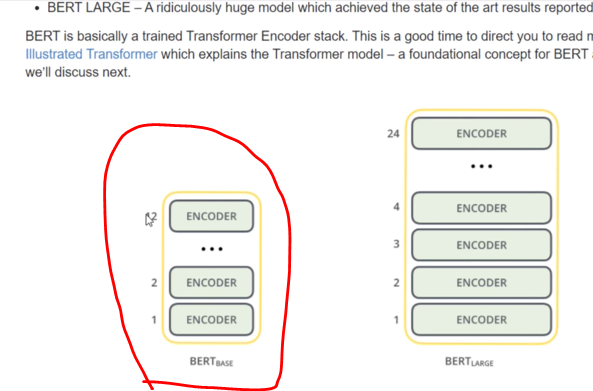

In [28]:
bert_results['encoder_outputs'][0]
#This is 1st layers encoded value

<tf.Tensor: shape=(2, 128, 768), dtype=float32, numpy=
array([[[ 0.12901434,  0.00644739, -0.03614964, ...,  0.04999623,
          0.06149194, -0.02657545],
        [ 1.1753381 ,  1.2140783 ,  1.1569982 , ...,  0.11634374,
         -0.35855365, -0.40490183],
        [ 0.03859044,  0.53869975, -0.21089798, ...,  0.21858174,
          0.7260166 , -1.1158605 ],
        ...,
        [-0.07587021, -0.2542192 ,  0.70755136, ...,  0.5054201 ,
         -0.18878664,  0.15028326],
        [-0.16066602, -0.28089672,  0.57597065, ...,  0.5275856 ,
         -0.11141399,  0.02887545],
        [-0.04428153, -0.20279591,  0.59093547, ...,  0.8133835 ,
         -0.39075813, -0.02601742]],

       [[ 0.1655082 ,  0.03928939, -0.03825998, ...,  0.0284854 ,
          0.14379606, -0.00523787],
        [ 0.5970513 ,  0.9677566 ,  0.10997115, ...,  0.74948275,
          0.8838973 ,  0.10995203],
        [ 1.2669257 ,  0.5595941 ,  0.6544118 , ...,  0.5853452 ,
          0.9448734 , -0.09817711],
        ...,

In [30]:
bert_results['encoder_outputs'][-1]
#This is the final or last layer outpt of encoded layers

<tf.Tensor: shape=(2, 128, 768), dtype=float32, numpy=
array([[[ 0.07292049,  0.08567821,  0.14476839, ..., -0.09677093,
          0.08722146,  0.07711097],
        [ 0.17839389, -0.19006066,  0.5034941 , ..., -0.05869843,
          0.3271714 , -0.15578581],
        [ 0.18701449, -0.43388772, -0.48875144, ..., -0.1550277 ,
          0.00145138, -0.24470966],
        ...,
        [ 0.12083028,  0.12884237,  0.46453524, ...,  0.07375555,
          0.17441934,  0.16522118],
        [ 0.07967854, -0.01190679,  0.5022541 , ...,  0.1377775 ,
          0.21002212,  0.00624582],
        [-0.0721269 , -0.2830347 ,  0.59033364, ...,  0.47551933,
          0.1666847 , -0.08920315]],

       [[-0.05533914,  0.1887488 , -0.19368494, ..., -0.1453175 ,
          0.21719882,  0.6776633 ],
        [ 0.3302325 ,  0.14483654, -0.35440895, ...,  0.08010809,
          0.45744348,  0.437999  ],
        [ 0.8402248 ,  0.9561045 ,  0.39044964, ...,  0.30778673,
          0.40883586,  0.3707441 ],
        ...,

### This ['encoder_outputs'][-1] the final encoded output, so this always same as sequence_output( which is encoded output for each word)

In [29]:
bert_results['encoder_outputs'][-1] == bert_results['sequence_output']

<tf.Tensor: shape=(2, 128, 768), dtype=bool, numpy=
array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]])>

In [32]:
bert_results['encoder_outputs']

[<tf.Tensor: shape=(2, 128, 768), dtype=float32, numpy=
 array([[[ 0.12901434,  0.00644739, -0.03614964, ...,  0.04999623,
           0.06149194, -0.02657545],
         [ 1.1753381 ,  1.2140783 ,  1.1569982 , ...,  0.11634374,
          -0.35855365, -0.40490183],
         [ 0.03859044,  0.53869975, -0.21089798, ...,  0.21858174,
           0.7260166 , -1.1158605 ],
         ...,
         [-0.07587021, -0.2542192 ,  0.70755136, ...,  0.5054201 ,
          -0.18878664,  0.15028326],
         [-0.16066602, -0.28089672,  0.57597065, ...,  0.5275856 ,
          -0.11141399,  0.02887545],
         [-0.04428153, -0.20279591,  0.59093547, ...,  0.8133835 ,
          -0.39075813, -0.02601742]],
 
        [[ 0.1655082 ,  0.03928939, -0.03825998, ...,  0.0284854 ,
           0.14379606, -0.00523787],
         [ 0.5970513 ,  0.9677566 ,  0.10997115, ...,  0.74948275,
           0.8838973 ,  0.10995203],
         [ 1.2669257 ,  0.5595941 ,  0.6544118 , ...,  0.5853452 ,
           0.9448734 , -0.09